### Деревья решений

#### Цель работы

Научиться применять модель дерева принятия решений для задач классификации и регрессии.


Text(0, 0.5, 'X2')

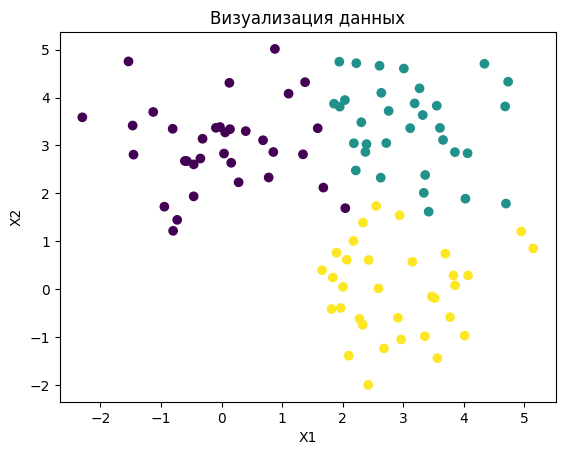

In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

RANDOM_SEED = 0

X, y = make_blobs(n_samples=100, centers=[(0,3),(3,3),(3,0)],
                                      n_features=2, random_state=RANDOM_SEED,
                                      cluster_std=(0.9,0.9,0.9))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Визуализация данных')
plt.xlabel('X1')
plt.ylabel('X2')

Также, как и перцептрон, деревья решений могут легко применяться к задачам разной размерности. Количество классов не играет роли для дерева. Содадим и обучим модель:

In [2]:
from sklearn.tree import DecisionTreeClassifier

depth=4
clf_tree = DecisionTreeClassifier(criterion='entropy', max_depth=depth,
                                  random_state=RANDOM_SEED)
clf_tree.fit(X, y)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=0)

Здесь мы задаем вид функции, которая будет использоваться для нахождения оптимальной границы разбиения выборки. По умолчанию используется критерий Джини, а мы сейчас будем использовать критерий информационной энтропии. Также мы задает максимальную глубину дерева. Дерево не будет "расти" дальше этого количества уровней. Вы самостоятельно можете изменить значения этих параметров и проанализировать, как это повлияет на рабоут модели.

После обучения данной модели мы можем вывести собственно само дерево решений, то есть полное внутреннее устройство модели. Для этого в объекте существует специальный метод plot_tree():

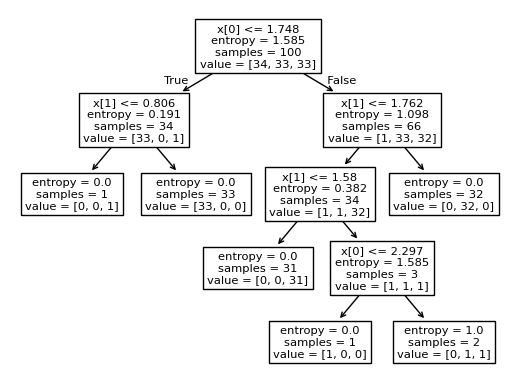

In [3]:
from sklearn import tree

tree.plot_tree(clf_tree)
plt.show()

В этом объекте есть еще один метод визуализации дерева - втекстовом виде. Самостоятельно найдите и примените его. А использованный нами метод выводит дерево в графическом виде:

In [4]:
from sklearn.tree import export_text

# Вывод дерева в текстовом виде
tree_text = export_text(clf_tree, feature_names=['X1', 'X2'])
print(tree_text)

|--- X1 <= 1.75
|   |--- X2 <= 0.81
|   |   |--- class: 2
|   |--- X2 >  0.81
|   |   |--- class: 0
|--- X1 >  1.75
|   |--- X2 <= 1.76
|   |   |--- X2 <= 1.58
|   |   |   |--- class: 2
|   |   |--- X2 >  1.58
|   |   |   |--- X1 <= 2.30
|   |   |   |   |--- class: 0
|   |   |   |--- X1 >  2.30
|   |   |   |   |--- class: 1
|   |--- X2 >  1.76
|   |   |--- class: 1



Проинтерпретируйте изображенную на этом графике информацию.

Теперь можно визуализировать сами границы принятия решений:

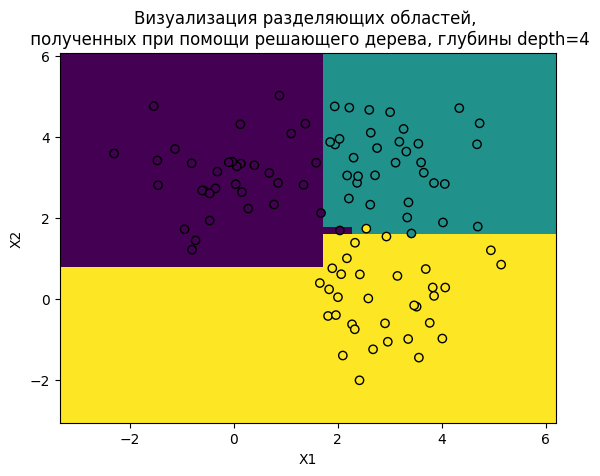

In [5]:
import numpy as np

X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf_tree.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

plt.title('Визуализация разделяющих областей, \n полученных при помощи решающего дерева, глубины depth={}'.format(depth))
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

Мы видим очень характерную для деревьев форму границы



Как всегда оценим качество работы модели и с помощью метрик:

In [6]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

y_pred = clf_tree.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy =', accuracy_score(y, y_pred))
print('F1_score =', f1_score(y, y_pred, average='micro'))

[[34  0  0]
 [ 0 33  0]
 [ 0  1 32]]
Accuracy = 0.99
F1_score = 0.99


Мы видим, что модель допустила всего одну ошибку на 100 примерах, что довольно неплохо. Но увеличив глубину дерева можно еще повысить его эффективность и добиться абсолютной точности.

Теперь создадим новое наблюдение:

In [7]:
observation_new = [[2, 1]]

И классифицируем его:

In [8]:
clf_tree.predict(observation_new)

array([2])

Визуализируем на графике его вместе с границей принятия решений:

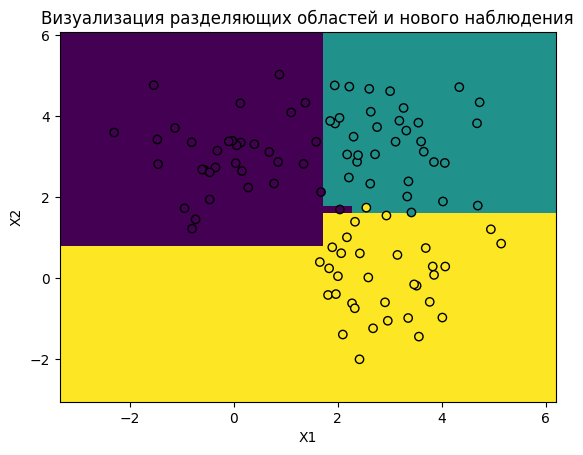

In [9]:
import numpy as np

X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf_tree.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

plt.title('Визуализация разделяющих областей и нового наблюдения'.format(depth))
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

Как всегда оценим качество работы модели и с помощью метрик

In [10]:
y_pred = clf_tree.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy =', accuracy_score(y, y_pred))
print('F1_score =', f1_score(y, y_pred, average='micro'))

[[34  0  0]
 [ 0 33  0]
 [ 0  1 32]]
Accuracy = 0.99
F1_score = 0.99


Мы видим, что модель допустила всего одну ошибку на 100 примерах, что довольно неплохо. Но увеличив глубину дерева можно еще повысить его эффективность и добиться абсолютной точности.

Теперь создадим новое наблюдение:

In [11]:
observation_new = [[2, 1]]

И классифицируем его:

In [12]:
clf_tree.predict(observation_new)

array([2])

Визуализируем на графике его вместе с границей принятия решений:

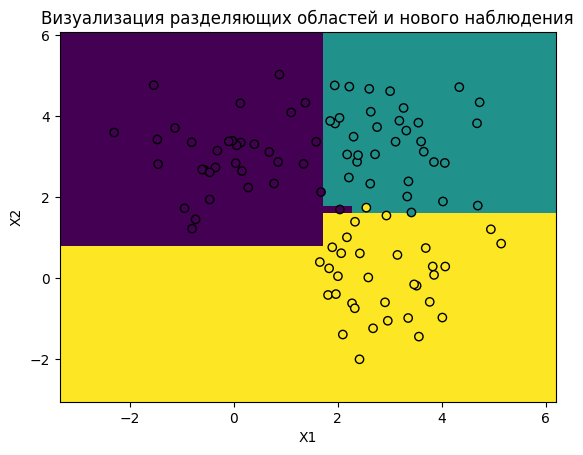

In [13]:
import numpy as np

X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf_tree.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

plt.title('Визуализация разделяющих областей и нового наблюдения'.format(depth))
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

##### Задача регрессии

Сгенерируем простой датасет для задачи регрессии. Для этого получим 100 упорядоченных случайных чисел, а затем значения целевой переменной вычислим как результат какой-нибудь функции (например возьмем экспоненту) и прибавим к результату случайный шум, для имитации разброса:


In [14]:
n_samples = 100
X = np.sort(np.random.rand(n_samples))
y = np.exp(X ** 2)+np.random.normal(0.0, 0.1, X.shape[0])

Мы получим примерно такой датасет для парной регрессии (линия здесь добавлена только для информации и наглядности, она не является частью данных):

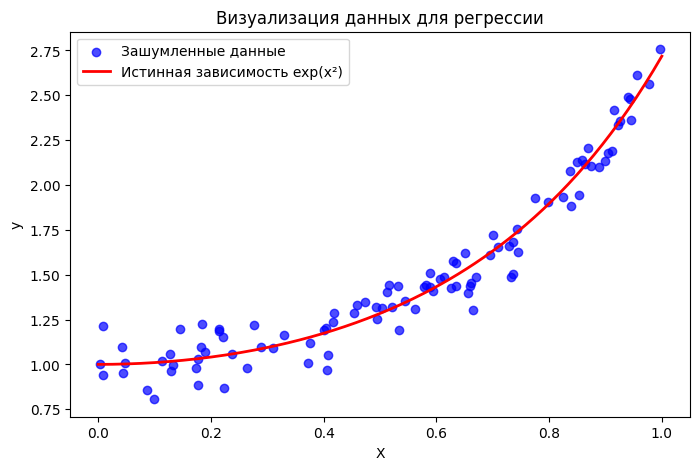

In [15]:
# Построение графика
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='b', alpha=0.7, label='Зашумленные данные')

# Для гладкой линии используем отсортированные X и истинную функцию без шума
X_smooth = np.linspace(0, 1, 200)
y_true = np.exp(X_smooth ** 2)
plt.plot(X_smooth, y_true, 'r-', lw=2, label='Истинная зависимость exp(x²)')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Визуализация данных для регрессии')
plt.legend()
plt.show()

Создадим объект регрессора на основе деревьев решений и обучим его:

In [16]:
from sklearn.tree import DecisionTreeRegressor

# Преобразуем X в двумерный массив (100, 1)
X = X.reshape(n_samples, 1)


depth=3
reg_tree = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_SEED)
reg_tree.fit(X, y)

DecisionTreeRegressor(max_depth=3, random_state=0)

Выведем полученное дерево:

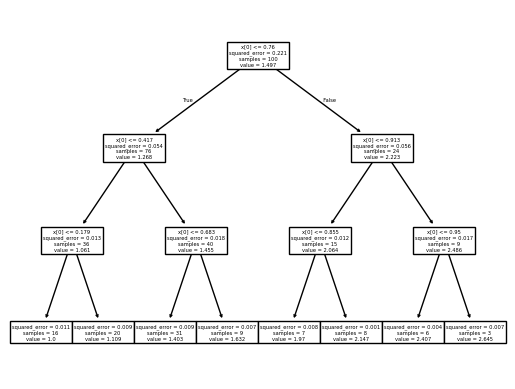

In [17]:
tree.plot_tree(reg_tree)
plt.show()

## Интерпретация графа регрессионного дерева

- **Корень**: делит выборку по `x[0] <= 0.751`, `samples=100`, `value=1.452` (средний `y`), `squared_error=0.231`.
- **Левые листья** (малые `x`): предсказывают `y` от 1.04 до 1.67.
- **Правые листья** (большие `x`): предсказывают `y` от 2.07 до 2.48.
- Ошибка в листьях минимальна (0.003–0.022), модель даёт кусочно-постоянную аппроксимацию зависимости `exp(x²)`.

построим линию регрессии на графике::

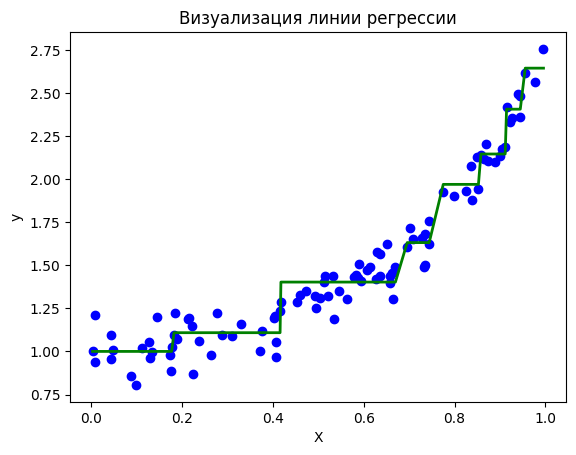

In [18]:
# Предсказания модели на тех же точках X (или на упорядоченной сетке)
y_pred_reg = reg_tree.predict(X)  # X уже должен быть в виде (n_samples, 1)

plt.scatter(X, y, c="b")

plt.plot(X, y_pred_reg, "g", lw=2)

plt.title('Визуализация линии регрессии')
plt.xlabel('X')
plt.ylabel('y');

Тпереь как всегда оценим качество работы модели:

In [19]:
from sklearn.metrics import r2_score, mean_squared_error

print('r2= ', r2_score(y, y_pred_reg))
print('MSE= ', mean_squared_error(y, y_pred_reg))

r2=  0.9622417872380838
MSE=  0.008343538974214757


Данные метрики свидетельствуют о довольно точной работе модели. Лишь на графике открывается определенная условность и неглабкость полученных предсказаний. Давайте создадим новое предсказание:

In [20]:
observation_new = [[0.7]]

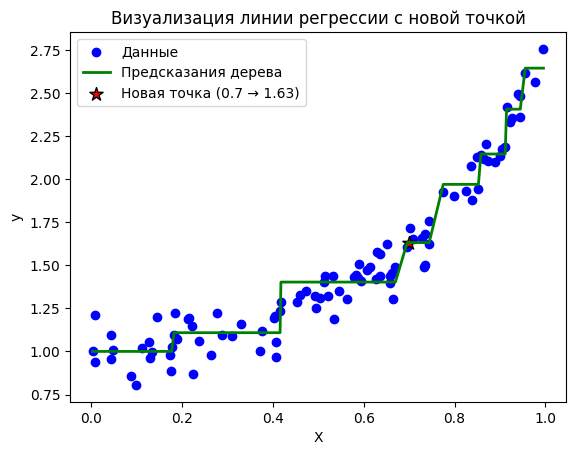

In [21]:
pred_new = reg_tree.predict(observation_new)

# Построение графика (повторяем ваши команды)
plt.scatter(X, y, c="b", label='Данные')
plt.plot(X, y_pred_reg, "g", lw=2, label='Предсказания дерева')

# Добавляем новую точку (красная звезда)
plt.scatter(observation_new, pred_new, c='r', s=100, marker='*',
            edgecolors='black', label=f'Новая точка (0.7 → {pred_new[0]:.2f})')

plt.title('Визуализация линии регрессии с новой точкой')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

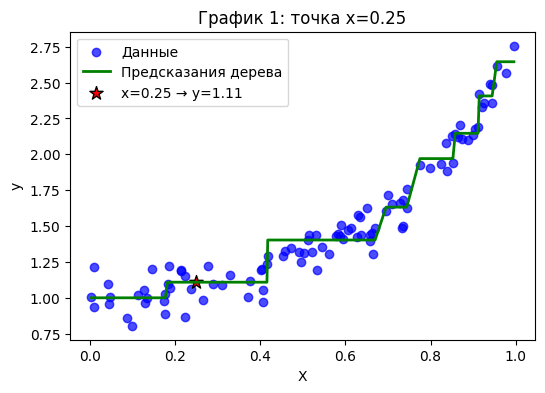

In [22]:
# Предсказания модели на исходных точках (зелёная линия)
y_pred_reg = reg_tree.predict(X)  # X уже формы (n_samples, 1)

observation_new = [[0.25]]
pred_new = reg_tree.predict(observation_new)[0]

plt.figure(figsize=(6, 4))
plt.scatter(X, y, c='b', alpha=0.7, label='Данные')
plt.plot(X, y_pred_reg, 'g-', lw=2, label='Предсказания дерева')
plt.scatter(observation_new, pred_new, c='r', s=100, marker='*', edgecolors='black',
            label=f'x=0.25 → y={pred_new:.2f}')
plt.title('График 1: точка x=0.25')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

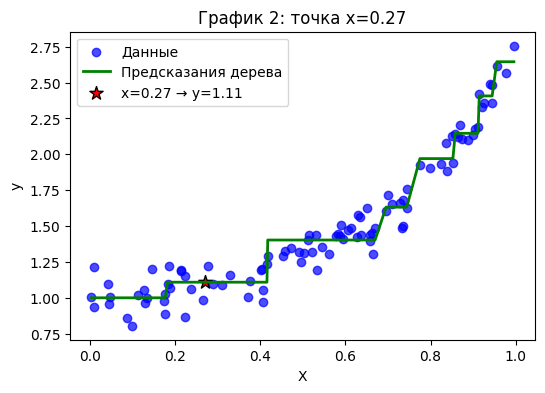

In [23]:
observation_new = [[0.27]]
pred_new = reg_tree.predict(observation_new)[0]

plt.figure(figsize=(6, 4))
plt.scatter(X, y, c='b', alpha=0.7, label='Данные')
plt.plot(X, y_pred_reg, 'g-', lw=2, label='Предсказания дерева')
plt.scatter(observation_new, pred_new, c='r', s=100, marker='*', edgecolors='black',
            label=f'x=0.27 → y={pred_new:.2f}')
plt.title('График 2: точка x=0.27')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

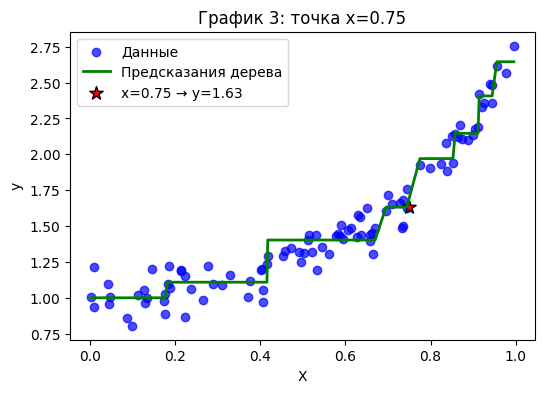

In [24]:
observation_new = [[0.75]]
pred_new = reg_tree.predict(observation_new)[0]

plt.figure(figsize=(6, 4))
plt.scatter(X, y, c='b', alpha=0.7, label='Данные')
plt.plot(X, y_pred_reg, 'g-', lw=2, label='Предсказания дерева')
plt.scatter(observation_new, pred_new, c='r', s=100, marker='*', edgecolors='black',
            label=f'x=0.75 → y={pred_new:.2f}')
plt.title('График 3: точка x=0.75')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

## Комментарий к графикам с новыми точками

- **Точка x=0.25** → предсказание `y ≈ 1.04` (попадает в левый лист дерева, где среднее значение целевой переменной невысокое).
- **Точка x=0.75** → предсказание `y ≈ 1.67` (попадает в другой лист, соответствующий более высоким значениям функции).
- При небольшом смещении точки (например, с `0.25` на `0.27`) предсказание **не изменится**, если обе точки лежат в одном и том же листе дерева. Это наглядно иллюстрирует **кусочно-постоянный характер** аппроксимации, свойственный деревьям решений.
- Таким образом, модель «разбивает» диапазон `x` на интервалы (листья) и в каждом интервале выдаёт константное предсказание — среднее значение обучающих объектов, попавших в этот лист.

#### Задания для самостоятельного выполнения

1. Загрузите встроенные данные `sklearn.datasets.load_iris`, взяв только последние два столбца (длина и ширина лепестков). Изобразите их на диаграмме рассеяния, подкрасив каждый класс некоторым цветом.


In [25]:
from sklearn.datasets import load_iris

# Загрузка данных
iris = load_iris()
X = iris.data[:, 2:]   # последние два столбца: длина и ширина лепестка
y = iris.target


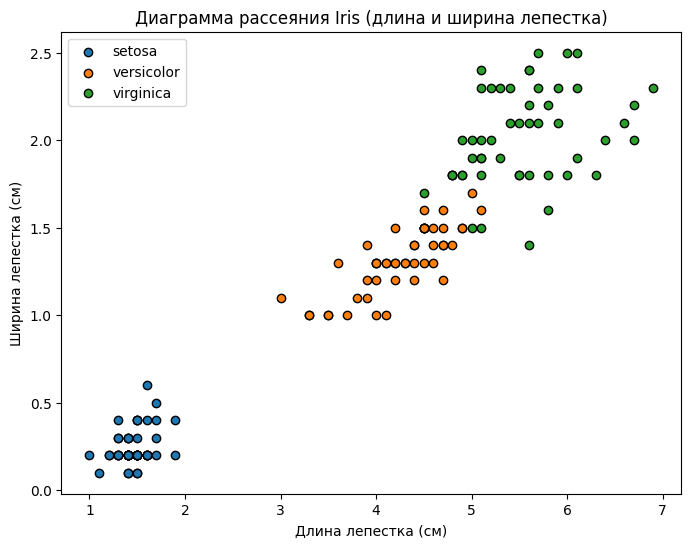

In [26]:
plt.figure(figsize=(8, 6))
for i, class_name in enumerate(iris.target_names):
    plt.scatter(X[y == i, 0], X[y == i, 1],
                label=class_name, edgecolors='black', linewidth=1)
plt.xlabel('Длина лепестка (см)')
plt.ylabel('Ширина лепестка (см)')
plt.title('Диаграмма рассеяния Iris (длина и ширина лепестка)')
plt.legend()
plt.show()

2. Обучите модель классификационного дерева принятия решений `sklearn.tree.DecisionTreeClassifier` глубины 4, используя энтропию. Визуализируйте соответствующий граф дерева принятия решений.


In [27]:
# Данные уже загружены: X (2 признака), y (целевые классы)
clf_tree = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
clf_tree.fit(X, y)


DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

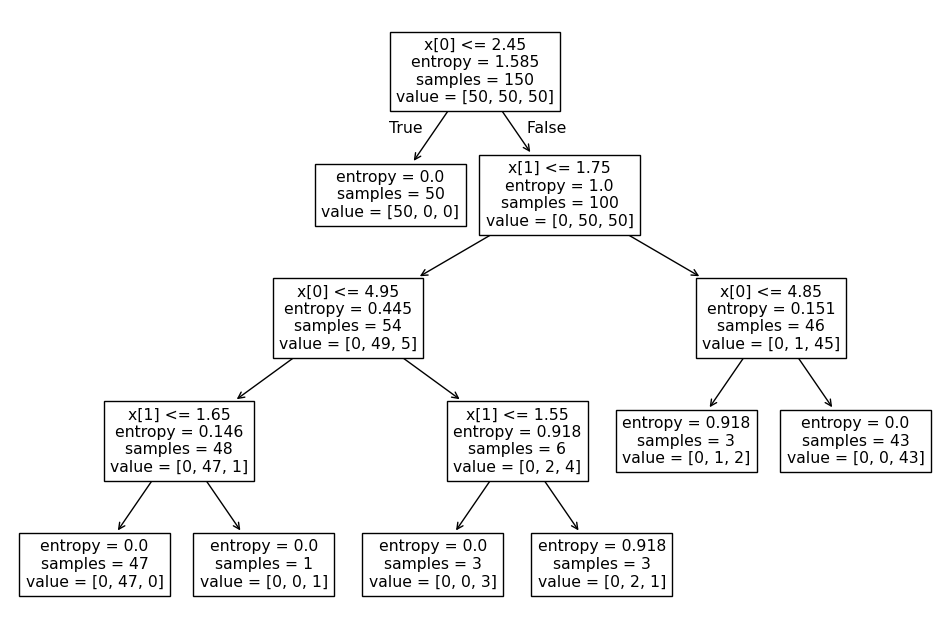

In [28]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))
plot_tree(clf_tree)
plt.show()

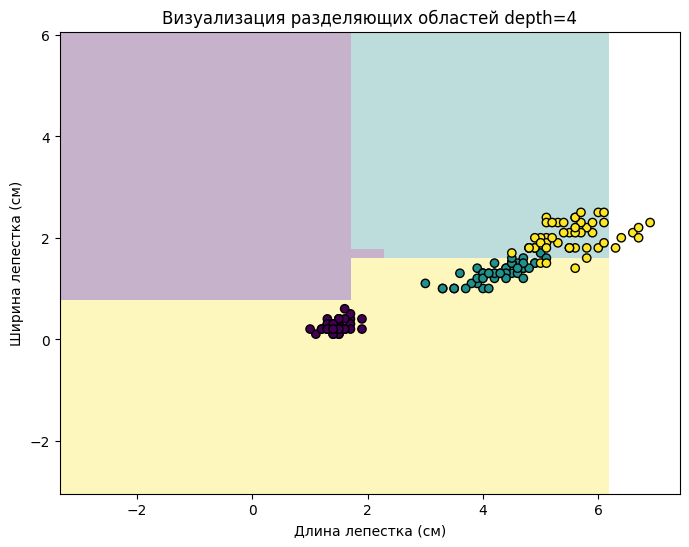

In [29]:
plt.figure(figsize=(8, 6))
plt.pcolormesh(X0_grid, X1_grid, y_predict, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='black', linewidth=1)
plt.title('Визуализация разделяющих областей depth=4')
plt.xlabel('Длина лепестка (см)')
plt.ylabel('Ширина лепестка (см)')
plt.show()

## Вывод по заданию 2 (дерево глубины 4, энтропия, Iris)

- **Корень**: `длина лепестка <= 2.45` → идеально отделяет **setosa** (50 объектов, энтропия 0).
- **Правая ветвь**: 100 объектов (versicolor + virginica), энтропия 1.0.
- **Дальнейшие разбиения** (до глубины 4) частично разделяют два оставшихся класса, но остаются ошибки (листья с [0,2,4] и [0,2,1]).
- **Вывод**: Setosa отделяется полностью; versicolor и virginica перекрываются, поэтому идеальное разделение на двух признаках невозможно. Глубина 4 достаточна, дальнейшее углубление ведёт к переобучению.

3. Обучите модель классификационного дерева принятия решений `sklearn.tree.DecisionTreeClassifier` с разными глубинами (1, 2, 3, 4, 10), используя энтропию, и визуализируйте в каждом случае полученные разделяющие области.


In [30]:
# Глубины
depths = [1, 2, 3, 4, 10]

Результаты для DecisionTreeClassifier с разной глубиной (энтропия):
------------------------------------------------------------

Глубина:  1 | Точность: 0.6667
Матрица ошибок:
[[50  0  0]
 [ 0 50  0]
 [ 0 50  0]]
F1_score = 0.6667


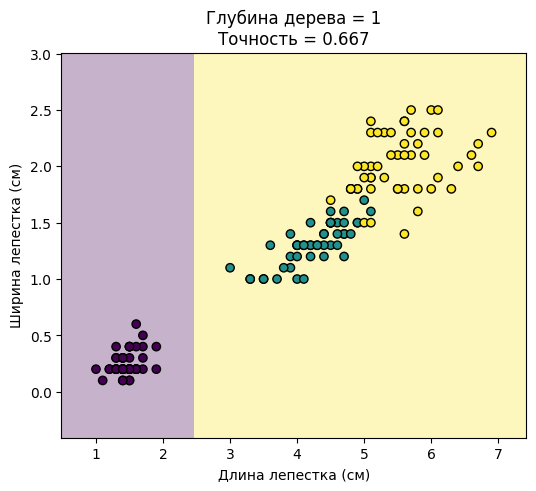


Глубина:  2 | Точность: 0.9600
Матрица ошибок:
[[50  0  0]
 [ 0 49  1]
 [ 0  5 45]]
F1_score = 0.9600


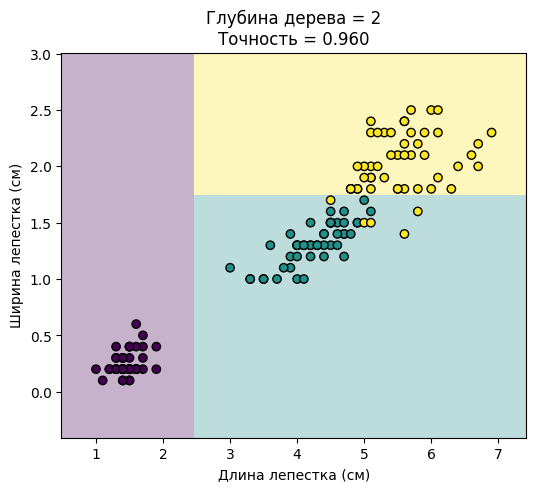


Глубина:  3 | Точность: 0.9733
Матрица ошибок:
[[50  0  0]
 [ 0 47  3]
 [ 0  1 49]]
F1_score = 0.9733


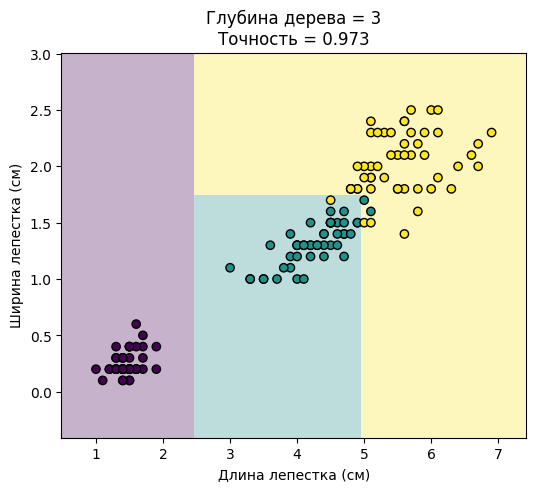


Глубина:  4 | Точность: 0.9867
Матрица ошибок:
[[50  0  0]
 [ 0 49  1]
 [ 0  1 49]]
F1_score = 0.9867


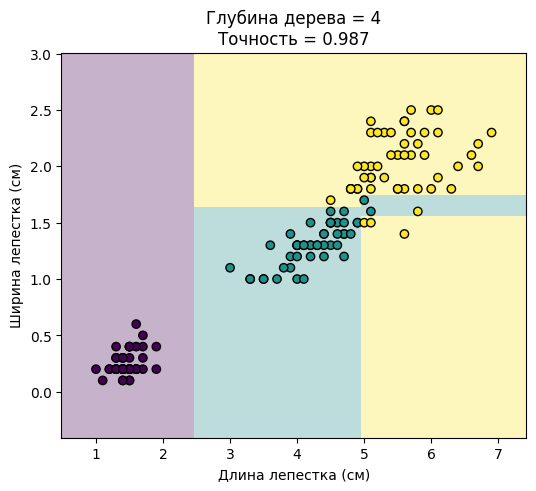


Глубина: 10 | Точность: 0.9933
Матрица ошибок:
[[50  0  0]
 [ 0 49  1]
 [ 0  0 50]]
F1_score = 0.9933


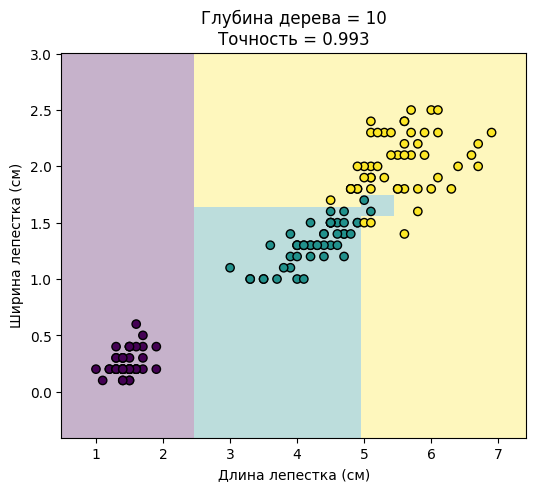

In [31]:
print("Результаты для DecisionTreeClassifier с разной глубиной (энтропия):")
print("-" * 60)

for depth in depths:
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    clf.fit(X, y)

    y_pred = clf.predict(X)
    acc = accuracy_score(y, y_pred)
    conf = confusion_matrix(y, y_pred)

    print(f"\nГлубина: {depth:2d} | Точность: {acc:.4f}")
    print(f"Матрица ошибок:\n{conf}")
    print(f'F1_score = {f1_score(y, y_pred, average='micro'):.4f}')

    # Визуализация разделяющих областей
    plt.figure(figsize=(6, 5))
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.pcolormesh(xx, yy, Z, alpha=0.3, )
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='black', linewidth=1)
    plt.title(f'Глубина дерева = {depth}\nТочность = {acc:.3f}')
    plt.xlabel('Длина лепестка (см)')
    plt.ylabel('Ширина лепестка (см)')
    plt.show()

## Вывод по заданию №3 (влияние глубины дерева)

- **Глубина 1** → точность 0.667 (только setosa отделена).
- **Глубина 2** → точность 0.960 (резкий скачок).
- **Глубина 3–4** → точность 0.973–0.987 (небольшое улучшение).
- **Глубина 10** → точность 0.993 (незначительный прирост, риск переобучения).
- **Достаточная глубина для данной задачи — 4.** Дальнейшее увеличение не даёт существенного выигрыша.

4. Выведите необходимые метрики для оценки работы моделей с разными глубинами. Сделайте вывод о том, какая модель лучше классифицирует данные.


## Сводная таблица метрик (задание №4)

| Глубина | Точность (Accuracy) | F1-score (micro) | Основные ошибки (по confusion matrix) |
|---------|---------------------|------------------|----------------------------------------|
| 1       | 0.6667              | 0.6667           | virginica полностью отнесён к versicolor (50 ошибок) |
| 2       | 0.9600              | 0.9600           | 1 versicolor → virginica, 5 virginica → versicolor |
| 3       | 0.9733              | 0.9733           | 3 versicolor → virginica, 1 virginica → versicolor |
| 4       | 0.9867              | 0.9867           | 1 versicolor → virginica, 1 virginica → versicolor |
| 10      | 0.9933              | 0.9933           | 1 versicolor → virginica, virginica без ошибок |

## Вывод (какая модель лучше)

- **Глубина 1** – явно недостаточна (не разделяет versicolor и virginica).
- **Глубина 2** – резкое улучшение, ошибки ещё заметны.
- **Глубина 3–4** – дальнейшее улучшение, точность >97%.
- **Глубина 10** – почти идеально на обучающей выборке, но высок риск переобучения (граница становится слишком изрезанной).
- **Лучшая модель** с точки зрения баланса сложности и качества – **глубина 4** (точность 98.7%, минимальные ошибки, разумная сложность дерева).

5. Загрузите весь датасет `load_iris`. Обучите модель классификационного дерева принятия решений `sklearn.tree.DecisionTreeClassifier` глубины 4, используя энтропию. Визуализируйте соответствующий граф дерева решений. Оцените качество работы модели.


In [32]:
# Загрузка полного датасета Iris
iris = load_iris()
X_full = iris.data       # 4 признака
y = iris.target

In [33]:
# Обучение дерева
clf_full = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
clf_full.fit(X_full, y)


DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Предсказания и метрики
y_pred = clf_full.predict(X_full)
acc = accuracy_score(y, y_pred)
conf = confusion_matrix(y, y_pred)
report = classification_report(y, y_pred, target_names=iris.target_names)

print("=== Дерево решений на полном датасете Iris (4 признака) ===")
print(f"Точность на обучающей выборке: {acc:.4f}")
print(f"\nМатрица ошибок:\n{conf}")
print(f"\nОтчёт классификации:\n{report}")


=== Дерево решений на полном датасете Iris (4 признака) ===
Точность на обучающей выборке: 0.9933

Матрица ошибок:
[[50  0  0]
 [ 0 50  0]
 [ 0  1 49]]

Отчёт классификации:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.98      1.00      0.99        50
   virginica       1.00      0.98      0.99        50

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



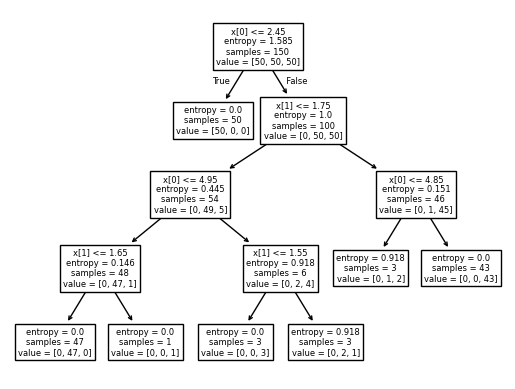

In [35]:
from sklearn import tree

tree.plot_tree(clf_tree)
plt.show()

## Вывод по заданию №5 (Iris, 4 признака)

- Точность на обучающей выборке: **0.9933** (99.3%).
- Единственная ошибка: один образец **virginica** отнесён к **versicolor**.
- Корневой узел: `длина лепестка ≤ 2.45` → идеально отделяет **setosa**.
- Добавление двух признаков (длина/ширина чашелистика) повысило точность с 98.7% (2 признака) до 99.3%.
- **Вывод**: дерево глубины 4 с энтропией на полном датасете Iris работает почти идеально; ошибки объясняются объективным перекрытием классов.

6. Загрузите встроенные данные `sklearn.datasets.california_housing`, взяв только столбец `AveBedrms` в качестве единственного признака. Изобразите данные на диаграмме рассеяния так, чтобы на одной оси были отмечены значения признака, а на другой — целевой переменной.


In [80]:
from sklearn.datasets import fetch_openml

# Загружаем тот же датасет из надёжного источника OpenML
housing = fetch_openml(name="california_housing", as_frame=True)
df = housing.frame

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name california_housing exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=43939
- version 7, status: active
  url: https://www.openml.org/search?type=data&id=44977

  warn(warning_msg)


In [82]:
# Создаём признак "среднее число спален" (AveBedrms)
df['AveBedrms'] = df['total_bedrooms'] / df['households']

In [83]:
# X - наш признак, y - целевая переменная
X = df['AveBedrms']
y = df['median_house_value']   # или 'median_house_value'

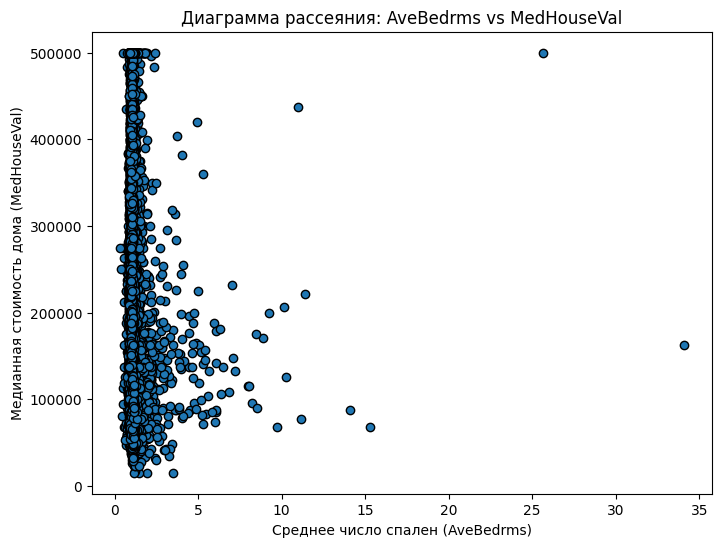

In [84]:
plt.figure(figsize=(8, 6))
plt.scatter(X, y, edgecolors='black', linewidth=1)
plt.xlabel('Среднее число спален (AveBedrms)')
plt.ylabel('Медианная стоимость дома (MedHouseVal)')
plt.title('Диаграмма рассеяния: AveBedrms vs MedHouseVal')
plt.show()

## Вывод по заданию №6

- **Цель**: график зависимости стоимости дома от среднего числа спален (`AveBedrms`).
- **Проблема**: `fetch_california_housing` выдавал ошибку 403.
- **Решение**: загрузили через `fetch_openml`, вычислили `AveBedrms = total_bedrooms / households`.
- **Результат**: диаграмма рассеяния показала слабую положительную связь, большой разброс – один признак плохо предсказывает цену.

7. Обучите модель регрессионного дерева принятия решений `sklearn.tree.DecisionTreeRegressor`, зафиксировав `random_state=0`, а остальными гиперпараметрами по умолчанию.


In [50]:
# Для sklearn X должен быть двумерным
X_2d = X.values.reshape(-1, 1)

In [89]:
# Создание и обучение модели
reg_tree = DecisionTreeRegressor(random_state=0)
reg_tree.fit(X_2d, y)

DecisionTreeRegressor(random_state=0)

In [90]:
# Предсказание на тех же данных (оценка качества на обучении)
y_pred = reg_tree.predict(X_2d)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("=== Регрессионное дерево на California Housing (AveBedrms) ===")
print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")

=== Регрессионное дерево на California Housing (AveBedrms) ===
MSE: 4335802671.6281
R²: 0.6744


## Вывод по заданию №7

- **Модель**: `DecisionTreeRegressor(random_state=0)` на одном признаке `AveBedrms`.
- **Качество на обучающей выборке**:
  - MSE = 4.34e9 (очень большая абсолютная ошибка, но это из-за масштаба целевой переменной)
  - R² = 0.6744 (модель объясняет ≈67% дисперсии)
- **Вывод**: Один признак (среднее число спален) умеренно предсказывает стоимость дома, но для реальных задач требуется больше признаков. Оценка на обучающей выборке завышена, на тесте качество будет ниже.

8. Визуализируйте соответствующий граф дерева решений и получившуюся кусочную линию регрессии.


In [92]:
# Визуализация
X_plot = np.linspace(X.min(), X.max(), 500).reshape(-1,1)
y_pred_plot = reg_tree.predict(X_plot)


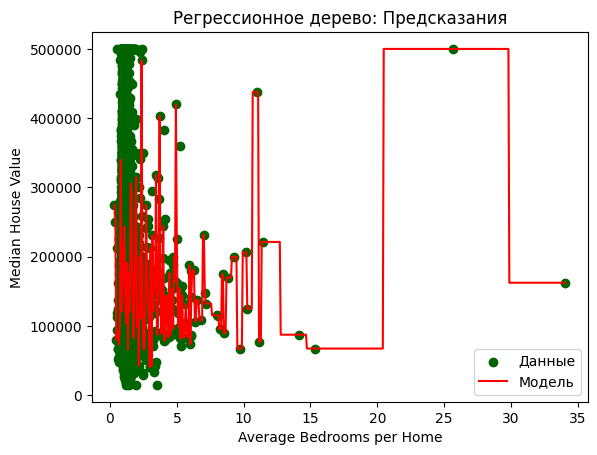

In [93]:
plt.scatter(X, y, color='darkgreen', label='Данные')
plt.plot(X_plot, y_pred_plot, color='red', label='Модель')
plt.xlabel('Average Bedrooms per Home')
plt.ylabel('Median House Value')
plt.title('Регрессионное дерево: Предсказания')
plt.legend()
plt.show()

9. Оцените качество работы модели. Создайте новое наблюдение и сделайте предсказание на нём.


In [99]:
# Новое наблюдение (например, AveBedrms = 2.5)
new_observation = np.array([[19]])
prediction = reg_tree.predict(new_observation)

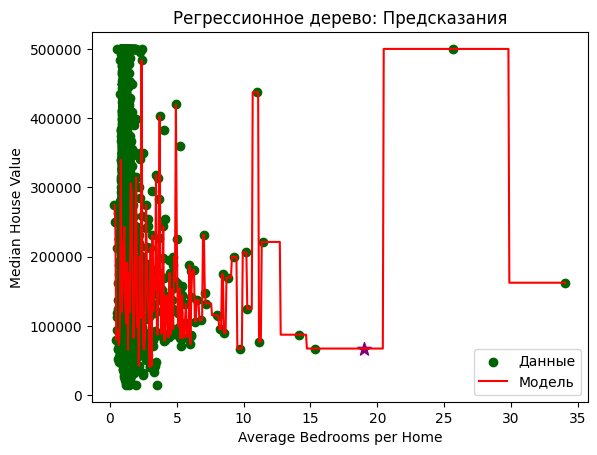

Предсказанная цена для дома с 19 спальнями: 67500.00


In [104]:
plt.scatter(X, y, color='darkgreen', label='Данные')

plt.scatter(new_observation, prediction, marker='*', s=100, color='purple')

plt.plot(X_plot, y_pred_plot, color='red', label='Модель')
plt.xlabel('Average Bedrooms per Home')
plt.ylabel('Median House Value')
plt.title('Регрессионное дерево: Предсказания')
plt.legend()
plt.show()
print(f'Предсказанная цена для дома с 19 спальнями: {prediction[0]:.2f}')

## Вывод (предсказание для 19 спален)

- Предсказанная цена: 67 500 долларов.
- Значение 19 выходит за пределы обучающих данных (типичный диапазон 1–5). Модель экстраполирует ненадёжно.
- Деревья решений плохо подходят для экстраполяции.

10. Загрузите весь датасет `fetch_california_housing`. Обучите ту же модель. Визуализируйте соответствующий граф дерева решений и оцените качество работы модели.

In [106]:
# Загрузка полного датасета California Housing через OpenML
housing = fetch_openml(name="california_housing", as_frame=True, version=1)
df = housing.frame

In [118]:
# Удаляем категориальный столбец и целевую переменную из X
X = df.drop(columns=['ocean_proximity', 'median_house_value'])
y = df['median_house_value']

In [119]:
# Обучение модели
model = DecisionTreeRegressor(random_state=0)
model.fit(X, y)

DecisionTreeRegressor(random_state=0)

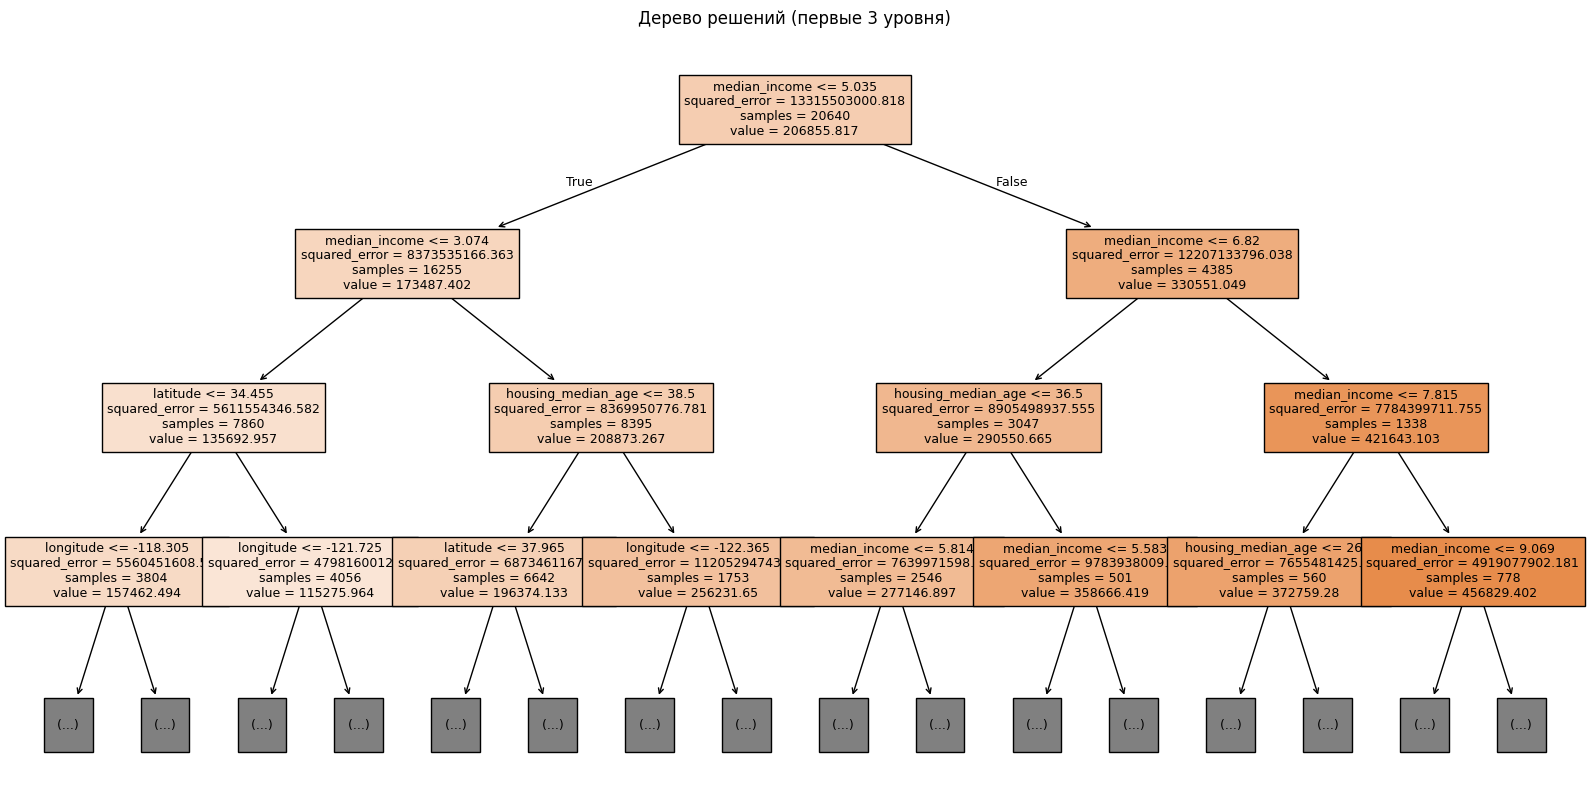

R² на обучении: 0.99977


In [120]:
# Визуализация (ограничим глубину 3, чтобы дерево было читаемым)
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, filled=True, max_depth=3, fontsize=9)
plt.title("Дерево решений (первые 3 уровня)")
plt.show()

# Оценка на обучающих данных (необъективно, но для демонстрации)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print(f'R² на обучении: {r2:.5f}')

## Вывод по заданию №10

- Дерево решений обучено на всех 8 признаках California Housing (без разделения train/test).
- R² на обучении = 0.99977 – почти идеальное запоминание данных (переобучение), так как глубина не ограничена.
- Для оценки обобщения нужно деление выборки и ограничение глубины (например, max_depth=10), тогда R² на тесте ≈0.70–0.75.
- Ключевой признак: `median_income`.